In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("../data/insurance_data.csv.txt", sep="|")

# show first rows
print(df.head())

# dataset shape
print(df.shape)

# columns
print(df.columns)

# missing values
print(df.isnull().sum())

C:\Users\user\AppData\Local\Temp\ipykernel_3464\3908491019.py:6: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data.csv.txt", sep="|")


   UnderwrittenCoverID  PolicyID     TransactionMonth  IsVATRegistered  \
0               145249     12827  2015-03-01 00:00:00             True   
1               145249     12827  2015-05-01 00:00:00             True   
2               145249     12827  2015-07-01 00:00:00             True   
3               145255     12827  2015-05-01 00:00:00             True   
4               145255     12827  2015-07-01 00:00:00             True   

  Citizenship          LegalType Title Language                 Bank  \
0              Close Corporation    Mr  English  First National Bank   
1              Close Corporation    Mr  English  First National Bank   
2              Close Corporation    Mr  English  First National Bank   
3              Close Corporation    Mr  English  First National Bank   
4              Close Corporation    Mr  English  First National Bank   

       AccountType  ...                    ExcessSelected CoverCategory  \
0  Current account  ...             Mobility - 

In [2]:
# create loss ratio
df["LossRatio"] = df["TotalClaims"] / (df["TotalPremium"] + 1)

# show first rows
df[["TotalPremium", "TotalClaims", "LossRatio"]].head()

,TotalPremium,TotalClaims,LossRatio
0,21.929825,0.0,0.0
1,21.929825,0.0,0.0
2,0.000000,0.0,0.0
3,512.848070,0.0,0.0
4,0.000000,0.0,0.0


In [3]:
overall_loss_ratio = df["LossRatio"].mean()

print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 3.0031161842531096


In [4]:
missing_values = df.isnull().sum()

missing_values.sort_values(ascending=False).head(20)

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
WrittenOff                  641901
Converted                   641901
Rebuilt                     641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
VehicleIntroDate               552
make                           552
Cylinders                      552
Model                          552
cubiccapacity                  552
kilowatts                      552
bodytype                       552
NumberOfDoors                  552
dtype: int64

In [5]:
df.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoors               

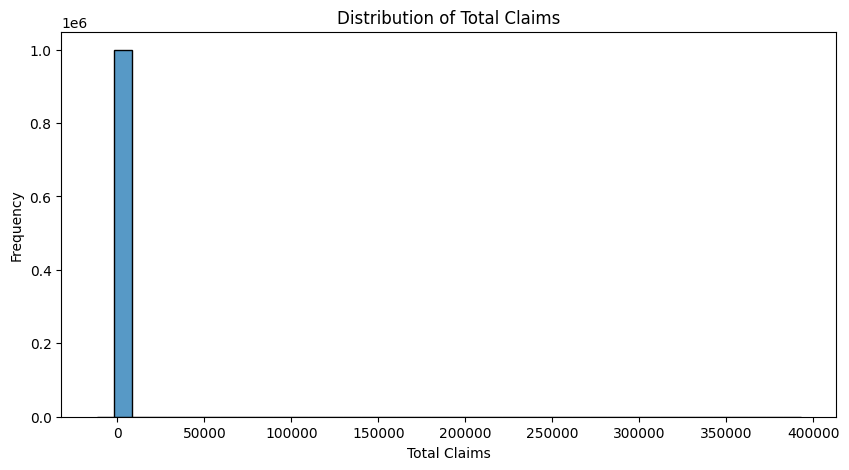

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalClaims"], bins=40)

plt.title("Distribution of Total Claims")

plt.xlabel("Total Claims")

plt.ylabel("Frequency")

plt.show()

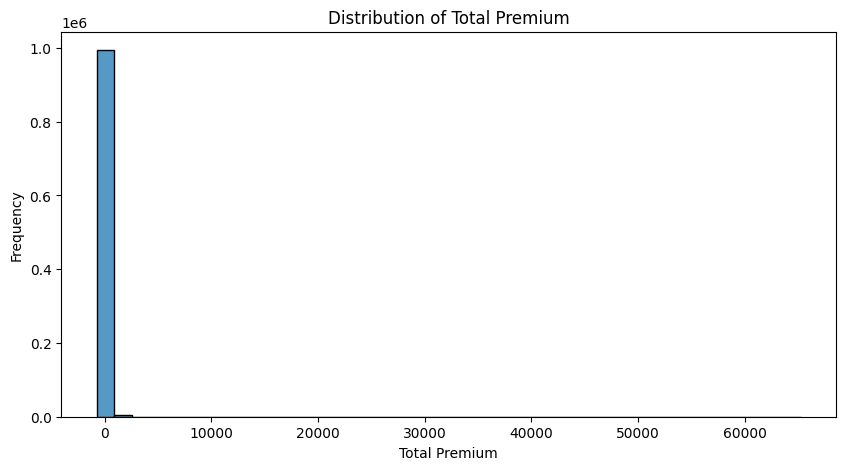

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["TotalPremium"], bins=40)

plt.title("Distribution of Total Premium")

plt.xlabel("Total Premium")

plt.ylabel("Frequency")

plt.show()

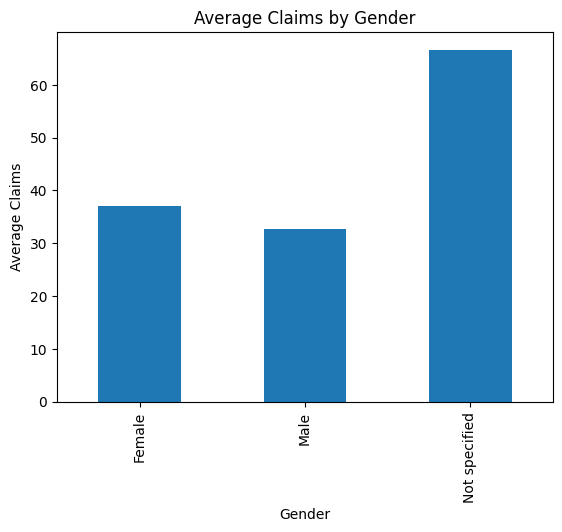

In [8]:
gender_claims = df.groupby("Gender")["TotalClaims"].mean()

gender_claims.plot(kind="bar")

plt.title("Average Claims by Gender")

plt.xlabel("Gender")

plt.ylabel("Average Claims")

plt.show()

In [9]:
province_risk = df.groupby("Province")["LossRatio"].mean().sort_values(ascending=False)

province_risk.head(10)

Province
Free State       11.059331
KwaZulu-Natal     4.735988
Gauteng           3.842191
North West        2.453431
Limpopo           1.235793
Western Cape      1.042654
Eastern Cape      0.482551
Mpumalanga        0.394116
Northern Cape     0.113167
Name: LossRatio, dtype: float64

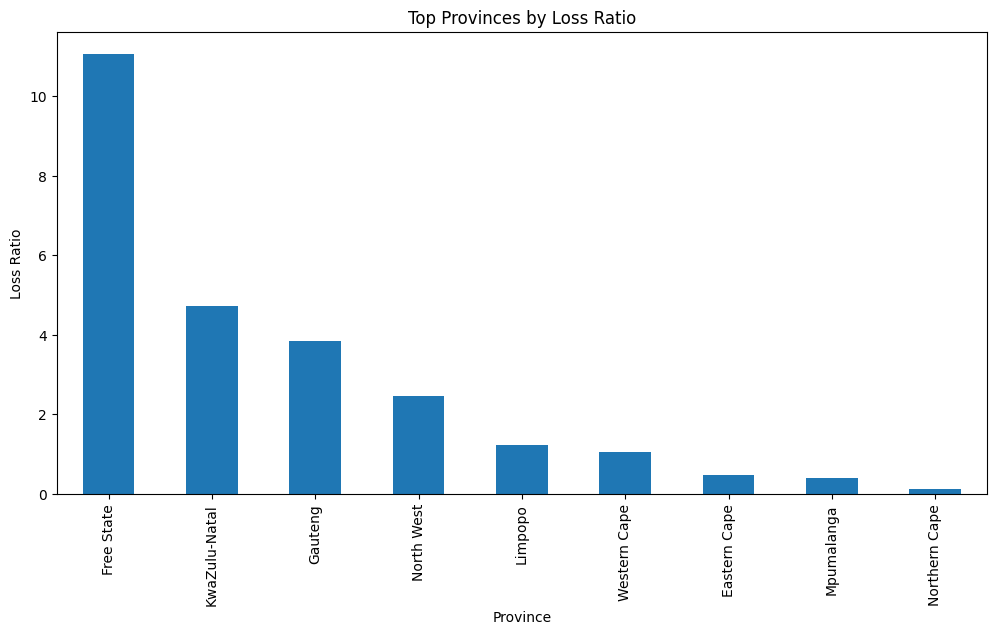

In [10]:
plt.figure(figsize=(12,6))

province_risk.head(10).plot(kind="bar")

plt.title("Top Provinces by Loss Ratio")

plt.xlabel("Province")

plt.ylabel("Loss Ratio")

plt.show()

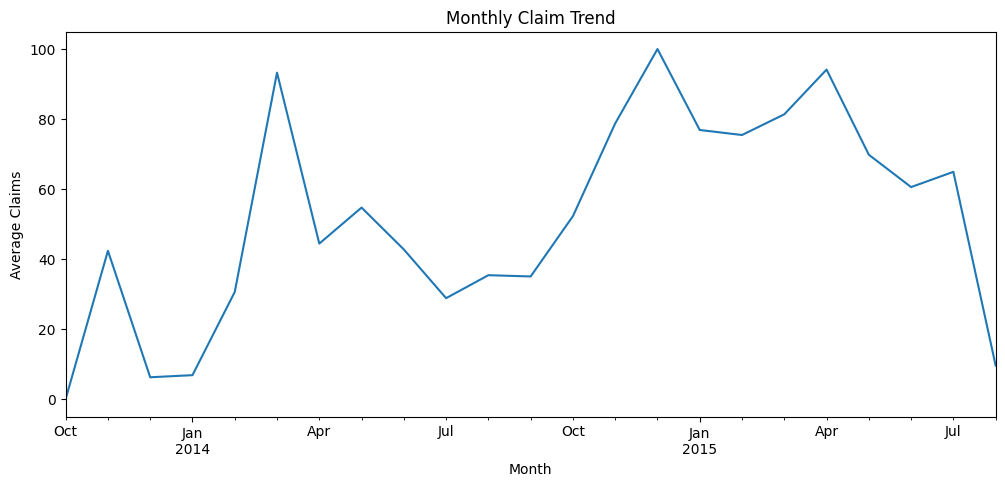

In [11]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

monthly_claims = df.groupby(df["TransactionMonth"].dt.to_period("M"))["TotalClaims"].mean()

monthly_claims.plot(figsize=(12,5))

plt.title("Monthly Claim Trend")

plt.xlabel("Month")

plt.ylabel("Average Claims")

plt.show()